In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task2.ipynb")

# Homework 3 - Task 2: Tree-Based Methods
## Predicting Water Potability Using Decision Trees and Random Forests

---


### Dataset

Access to safe drinking water is a fundamental public health concern. This dataset contains physicochemical measurements for 3,276 water samples, each labeled as potable or non-potable.

| Feature | Description |
|---|---|
| `ph` | pH value of water (0–14 scale) |
| `Hardness` | Capacity to precipitate soap (mg/L) |
| `Solids` | Total dissolved solids (ppm) |
| `Chloramines` | Amount of chloramines (ppm) |
| `Sulfate` | Amount of sulfates dissolved (mg/L) |
| `Conductivity` | Electrical conductivity (μS/cm) |
| `Organic_carbon` | Amount of organic carbon (ppm) |
| `Trihalomethanes` | Amount of trihalomethanes (μg/L) |
| `Turbidity` | Measure of light-emitting property (NTU) |

#### Response Variable

| Column | Description |
|---|---|
| `Potability` | Binary flag — `1` if water is safe to drink, `0` otherwise |


 **Note:** Several features contain missing values (`ph`, `Sulfate`, `Trihalomethanes`). You will handle these in the preprocessing step.

 This dataset comes from Kaggle and can be found [here](https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability).

### Setup: Load Libraries

Run the cell below to import all required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Step 1: Load the Data

Read `water_potability.csv` into a DataFrame. Preview the first few rows and confirm its shape.

In [3]:
df = pd.read_csv('water_potability.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### Step 2: Explore the Data

Before modeling, examine the distribution of your response variable and the number of NAs. Understanding both will guide preprocessing decisions.

In [4]:
# Count potable vs non-potable samples and check missing values
print(df['Potability'].value_counts())
print(df.isna().sum())

Potability
0    1998
1    1278
Name: count, dtype: int64
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


### Step 3: Preprocess the Data

Three features have missing values. A simple approach for tree-based methods is to **impute with the column median**. Impute the missing values using `df.fillna()`.Store your cleaned dataframe in a variable called `df_clean`. 

After imputation, split the data 70/30 into training and test sets, stratifying on `Potability` to preserve the class ratio in both splits.Store your results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [5]:
# Fill missing values with the median of each column
df_clean = df.fillna(df.median())

# Seperate predictors and response
X = df_clean.drop(columns = 'Potability')
y = df_clean['Potability']

# 70/30 train-test split, preserving class ratio
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.30,
                                                    stratify = y,
                                                    random_state = 42)

In [6]:
grader.check("q1")

q1 results: All test cases passed!

### Step 4: Fit a Single Classification Tree

Start with an **unpruned** classification tree (no constraints on depth or leaf size). This gives a baseline and illustrates the overfitting problem that ensemble methods address.

Fit `DecisionTreeClassifier` with only `random_state=42` set (all other parameters at defaults). Report the tree depth in a variable named `tree_depth`. Calculate both the train accuracy and the test accuracy, storing the train accuracy in a variable called`dt_unpruned_acc_train` and the test accuracy in a variable called `dt_unpruned_acc_test`. 

In [7]:
# Fit unpruned decision tree
dt_unpruned = DecisionTreeClassifier(random_state = 42)
dt_unpruned.fit(X_train, y_train)

# Find the depth of decision tree 
# Check accuracy on train / test data
tree_depth = dt_unpruned.get_depth()
dt_unpruned_acc_train = accuracy_score(y_train, 
                                       dt_unpruned.predict(X_train))
dt_unpruned_acc_test  = accuracy_score(y_test,
                                       dt_unpruned.predict(X_test))

print('Tree depth:', tree_depth)
print('Train accuracy:', dt_unpruned_acc_train)
print('Test accuracy', dt_unpruned_acc_test)

Tree depth: 33
Train accuracy: 1.0
Test accuracy 0.5808748728382502


In [8]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: How does the training accuracy and test accuracy differ? What does this mean about your model?**

_The unpruned decision tree achieved a training accuracy of **1.0** (100%) and a test accuracy of approximately **0.581** (58.1%). This large difference shows that the model overfit the training data. With a tree depth of **33** and no restrictions, the model memorized the training set instead of learning pattern that generalize well to new data. In other words, the model learned the training data too specifically, so it performed poorly on new water samples._

<!-- END QUESTION -->

### Step 5: Tune Tree Depth with Cross-Validation

A fully grown tree memorizes the training data (better training accuracy, poor test accuracy). We need to find the right **depth** to prevent this. 

Using 5-fold cross-validation on the training set, compute mean CV accuracy for `max_depth` from 1 to 20. Identify the optimal depth using `np.argmax`, storing it in a variable called `optimal_depth`. Plot the CV Accuracy against the 20 different depths, adding a vertical line at the optimal depth. 

In [9]:
# Try depths 1 through 20
depths = range(1, 21)

# Store mean CV accuracy for each depth
cv_scores = []

# Loop through every depth value
for depth in depths:
    
    # Create a decision tree model and perform 5-fold CV
    # We want to find most reliable estimate of model performance
    dt = DecisionTreeClassifier(max_depth = depth,
                                random_state = 42)
    scores = cross_val_score(dt, X_train, y_train, 
                             cv = 5, scoring = 'accuracy')
    
    # Save mean accuracy
    cv_scores.append(scores.mean())

# Find the index position of the highest accuracy and get best depth
optimal_depth = depths[np.argmax(cv_scores)]
print('Optimal depth:', optimal_depth)

Optimal depth: 7


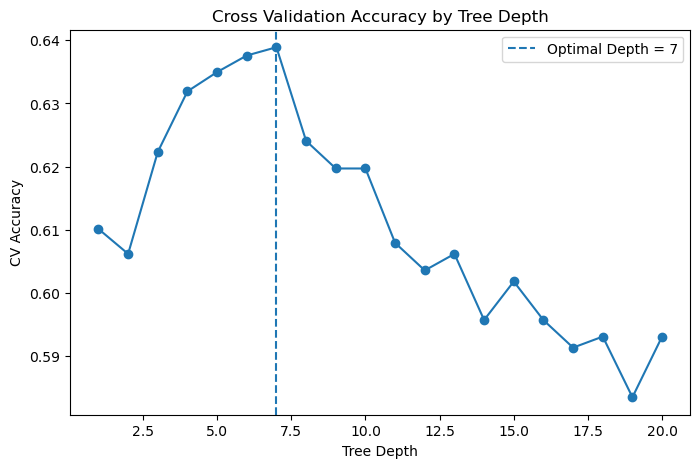

In [10]:
# Plot CV Results
plt.figure(figsize = (8, 5))

# Plot depth vs accuracy
plt.plot(depths, cv_scores, marker = 'o')

# Add vertical line for best depth
plt.axvline(optimal_depth, linestyle = '--', 
            label = f'Optimal Depth = {optimal_depth}')

# Add label
plt.xlabel('Tree Depth')
plt.ylabel('CV Accuracy')
plt.title('Cross Validation Accuracy by Tree Depth')

plt.legend()
plt.show()

In [11]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2: What did cross fold validation find the optimal depth to be? Explain what these means in plain language.**

_Cross-validation found the optimal tree depth to be **7**. This means that a tree with a maximum depth of 7 provided the best balance between learning useful patterns in the data and avoiding overfitting. Trees with smaller depths were likely too simple, while deeper trees became too complex and memorized the training data. To summarize, a **depth of 7** was the *sweet spot* where the model was detailed enough to make good predictions without becoming overly specific to the training data._

<!-- END QUESTION -->

### Step 6: Fit the Tuned Decision Tree

Refit the decision tree using `optimal_depth` and evaluate on the held-out test set. Store the test accuracy in a variable called `acc_dt`. 

In [12]:
# Create decision tree using optimal depth
dt_opt = DecisionTreeClassifier(max_depth = optimal_depth,
                                  random_state = 42)

# Train model and predict on test set
dt_opt.fit(X_train, y_train)
y_pred_tuned = dt_opt.predict(X_test)

# Compute test accuracy
acc_dt = accuracy_score(y_test, y_pred_tuned)
print('Tuned Tree Accuracy:', acc_dt)

Tuned Tree Accuracy: 0.6459816887080366


In [13]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q3: Did the accuracy on your tuned decision tree improve compared to your untuned tree? If so, why do you think it improved?**

_The tuned decision tree improved compared to the untuned tree. The unpruned tree had a test accuracy of approximately **0.581**, while the tuned tree acheived a higher test accuracy of about **0.646**. Limiting the tree depth to 7 reduced overfitting. The smaller tuned tree made better predictions because it focused on the most important patterns instead of memorizing the training data._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 7: Visualize the Decision Tree

Plot the tuned tree using `plot_tree`. Save the tree as an image to evaluate the results and answer **Q5**. 

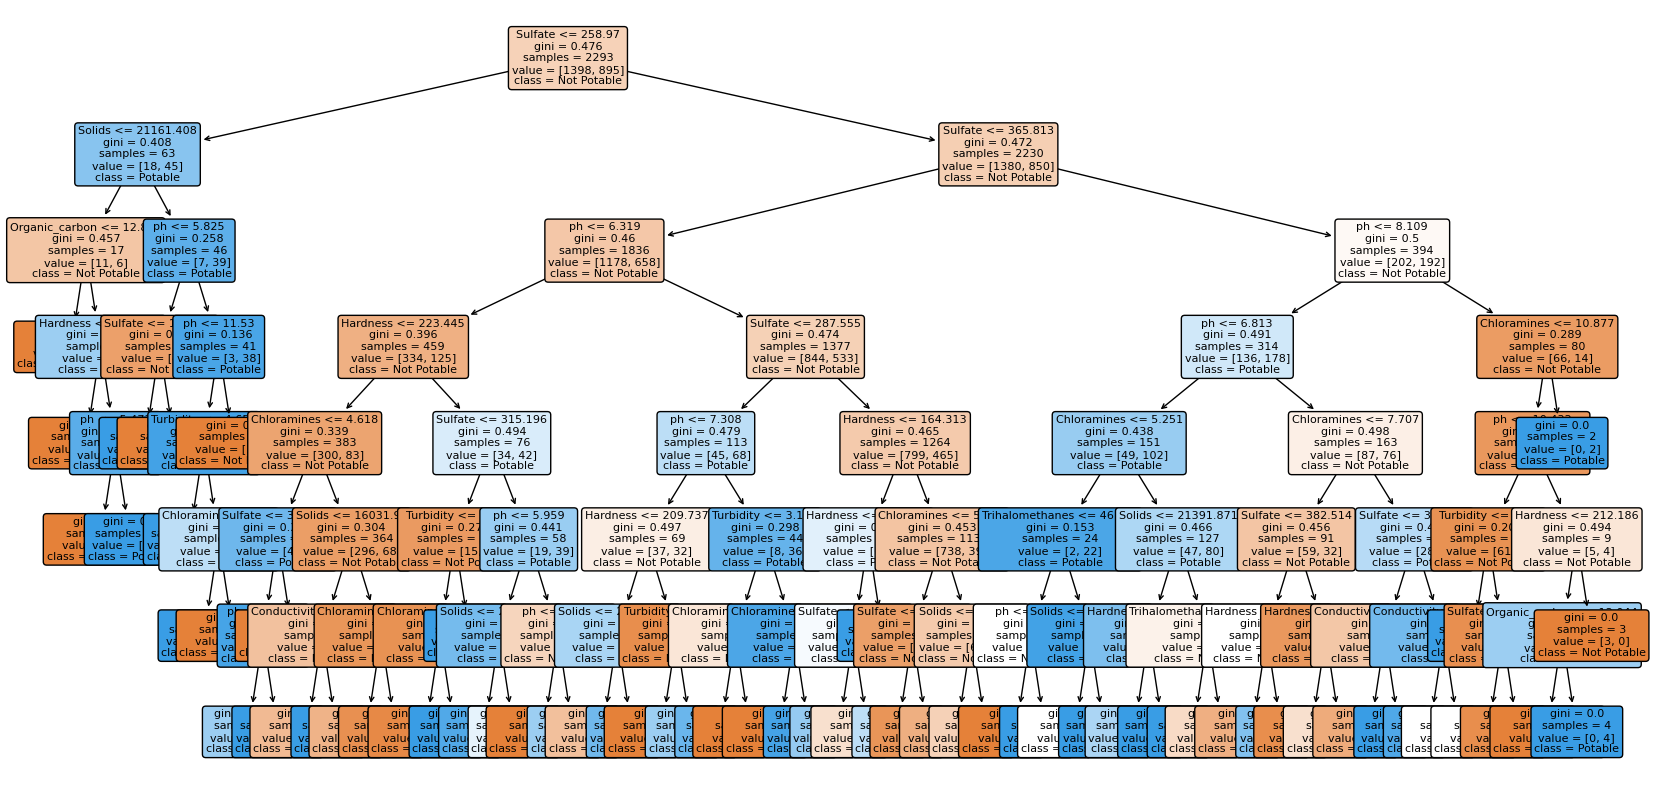

In [14]:
# Plot the tuned tree using the best depth found from CV
plt.figure(figsize = (20, 10))

# Plot the decision tree by using visualizing model, use feature names,
# And label class predictions
plot_tree(dt_opt, feature_names = X.columns,
          class_names = ['Not Potable', 'Potable'],
          filled = True,
          rounded = True,
          fontsize = 8)
plt.show()

> **Q4: Examine the root node and first two levels of the tree. Which feature is used for the root split, and what threshold does it use? What does this tell you about that feature's relationship with potability? What is the Gini impurity at the root, and how does it change after the first split?**

_The root node uses `Sulfate` with a threshold of about **258.97** for the first split. This shows that sulfate levels are important for predicting water potability. The root node has a Gini impurity of **0.476**, and after the first split it decreases slightly to about **0.408** and **0.472**, meaning the data becomes a little more organized after splitting. In other words, the model found sulfate to be one of the most useful features for seperating potable and not potable water samples._

<!-- END QUESTION -->

### Step 8: Random Forest

**Random forests** address the high variance of a single tree by fitting many trees on bootstrap samples of the training data and averaging their predictions. To further reduce correlation among the trees, at each split only a random subset of $m$ features is considered (by default sklearn uses $m = \lfloor\sqrt{p}\rfloor$ for classification).

Fit a `RandomForestClassifier`, called `rf` with `n_estimators=200`. Report the accuracy and store it in `acc_rf`. 

In [15]:
# Create random forest model
rf = RandomForestClassifier(n_estimators = 200, random_state = 42)

# Train the random forest and predict on test data
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Train the random forest
acc_rf = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy:', acc_rf)

Random Forest Accuracy: 0.6612410986775178


In [16]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q5: Compare the test results of Decision Tree and Random Forest? Which performed beter? Why do you think this is?**

_The Random Forest performed better than the Decision Tree. The tuned Decision Tree had a test accuracy of about **0.646**, while the Random Forest achieved a higher accuracy of about **0.661**. The Random Forest slightly outperformed the tuned tree (**66.1% vs 64.6%**), likely because averaging predictions from multiple trees reduces variance and overfitting more effectively than a single tree, even when tuned. This helps **reduce overfitting** and improves the model's ability to generalize to new data which suggests that the Random Forest made better predictions becuase it used many trees working together instead of depending on a single decision tree._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 9: Feature Importances

Both decision trees and random forests assign an **importance score** to each feature based on the total reduction in impurity (Gini) it produces across all splits. Random forest importances are averaged over all trees in the ensemble, making them more stable than a single tree's importances.

Create a bar plot showing the feature importances from the tuned decision tree and the random forest side by side. You can access the feature importants from the model wtih `model.feature_importances_`.

In [17]:
# Extract importances values from decision tree & random forest
dt_importances = dt_opt.feature_importances_
rf_importances = rf.feature_importances_

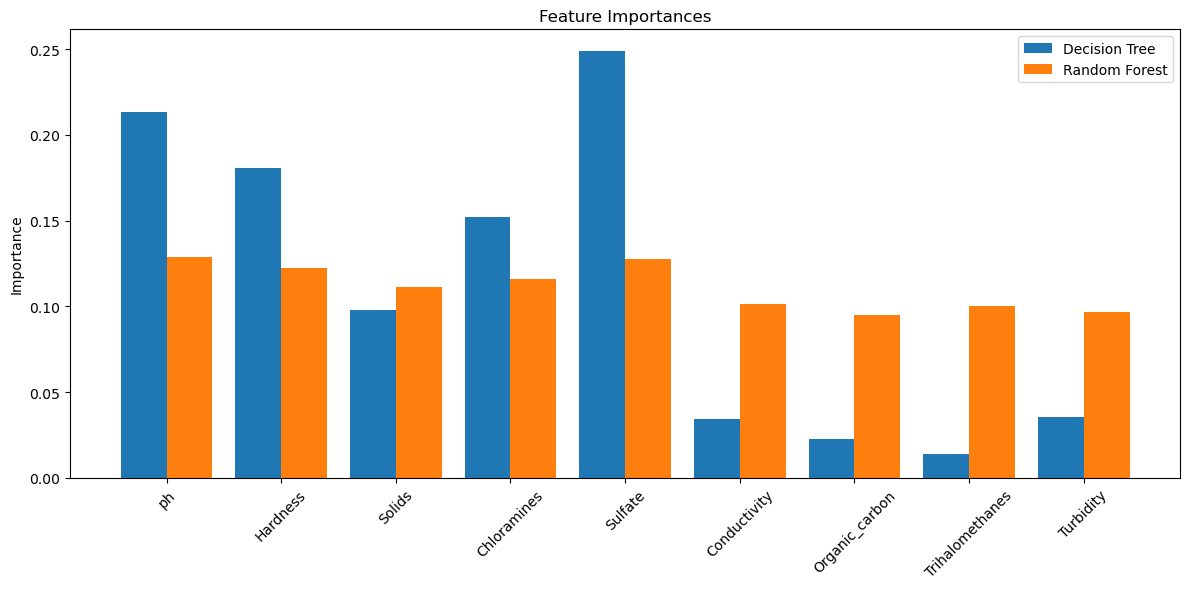

In [18]:
# Create x-axis positions
x = np.arange(len(X.columns))

# Plot decision tree & random forest importances
plt.figure(figsize = (12, 6))
plt.bar(x - 0.2, dt_importances, width = 0.4, label = 'Decision Tree')
plt.bar(x + 0.2, rf_importances, width = 0.4, label = 'Random Forest')

# Add feature names on x-axis
plt.xticks(x, X.columns, rotation = 45)

# Label axes and title
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.legend()
plt.tight_layout()
plt.show()

> **Q6: Do the decision tree and random forest agree on which features are most important? If they differ, why might a single tree's importances be less reliable than the random forest's? Which feature appears most important for predicting potability, and does that make physical sense?**

_The Decision Tree and Random Forest agree that features like `Sulfate`, `ph`, `Hardness`, and `Chloramines` are important for predicting water potability; however, the Decision Tree relies more heavily on a few features while the Random Forest distributes importance more evenly. A single Decision Tree's importances are less reliable because small changes in the data can greatly affect the tree structure, while the Random Forest averages results across many trees, making it more stable. `Sulfate` appears to be the most important feature overall, especially in the Decision Tree model. This makes physical sense because sulfate levels are strongly related to water quality and can affect whether water is considered safe to drink. Overall, the Random Forest provides a more balanced and dependable view of which features matter most._

<!-- END QUESTION -->

### Step 10: Confusion Matrix

Create a confusion matrix for the random forest model using `ConfusionMatrixDisplay`. Label your response variable as `Not Potable`/ `Potable` in the confusion matrix (instead of `0`/`1`).

In [19]:
# Compute confusion matrix values
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)

[[538  62]
 [271 112]]


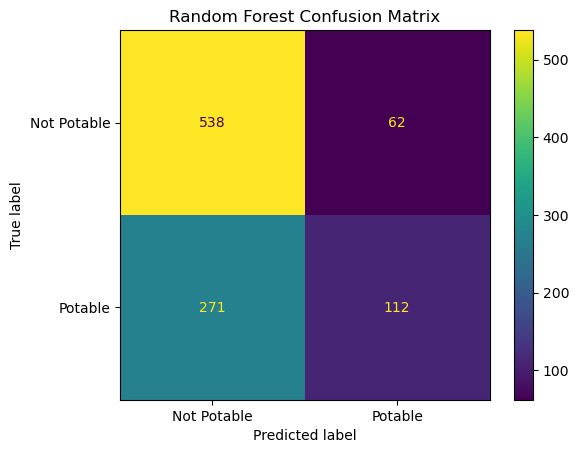

In [20]:
# Create confusion matrix display
display = ConfusionMatrixDisplay(confusion_matrix = cm,
                                 display_labels = ['Not Potable',
                                                   'Potable'])

# Plot confusion matrix
display.plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

<!-- BEGIN QUESTION -->

> **Q7:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

_True Negatives (TN): 538 & unsafe water correctly predicted as unsafe._

_False Positives (FP): 62 & unsafe water incorrectly predicted as safe to drink._

_False Negatives (FN): 271 & safe water incorrectly predicted as unsafe._

_True Positives (TP): 112 & safe water correctly predicted as safe to drink._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Step 11: Model Comparison

Create a table or bar chart comparing test accuracy across all three models.

In [21]:
# Create comparison table that evaluates model accuracies
results = pd.DataFrame({
    'Model': ['Unpruned Tree', 'Tuned Tree', 'Random Forest'],
    'Test Accuracy': [dt_unpruned_acc_test, acc_dt, acc_rf]})

# Display table
print(results)

           Model  Test Accuracy
0  Unpruned Tree       0.580875
1     Tuned Tree       0.645982
2  Random Forest       0.661241


> **Q8:** Which model achieved the highest test accuracy? Comparing the unpruned and tuned decision tree, how much did pruning improve accuracy? What does this tell you about overfitting in the unpruned tree?


_the Random Forest achieved the highest test accuracy at approximately **0.661**, followed by the tuned Decision Tree at **0.646**, while the unpruned tree had the lowest test accuracy at **0.581**. Pruning improved the Decision Tree's accuracy by about **0.065** (6.5 percentage points). This shows that the unpruned tree was overfitting the training data by memorizing patterns that did not generalize well to new samples, while pruning helped the model focus on more meaningful patterns. Thus, limiting the tree depth made the model **more reliable** on unseen data by reducing overfitting._

---

Run the cell below to receive credit for autograded questions. 

In [22]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!